Exploratory Data Analysis - EDA

--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB
None

--- Descriptive Statistics (Numerical Features) ---
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308

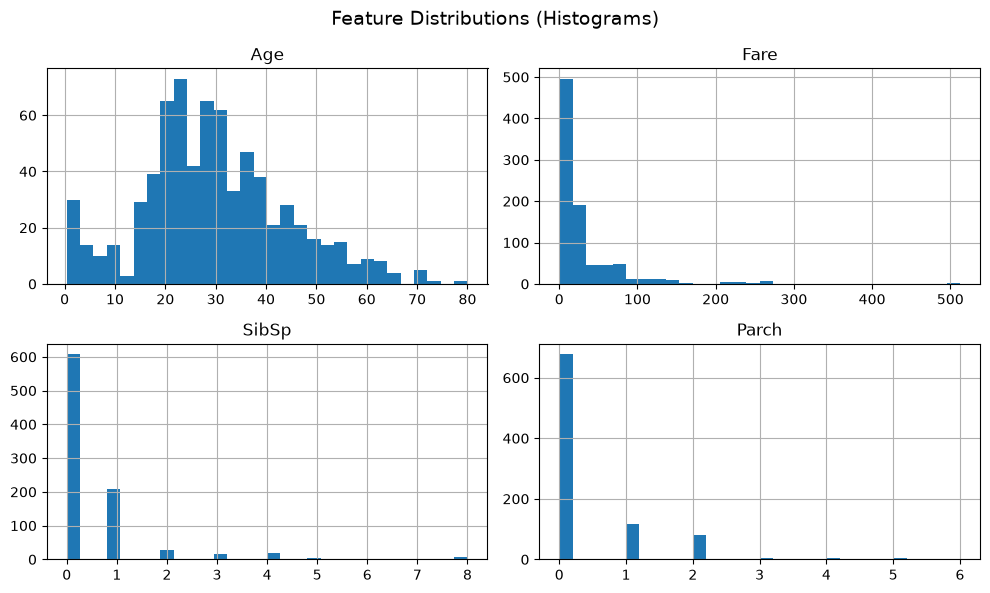

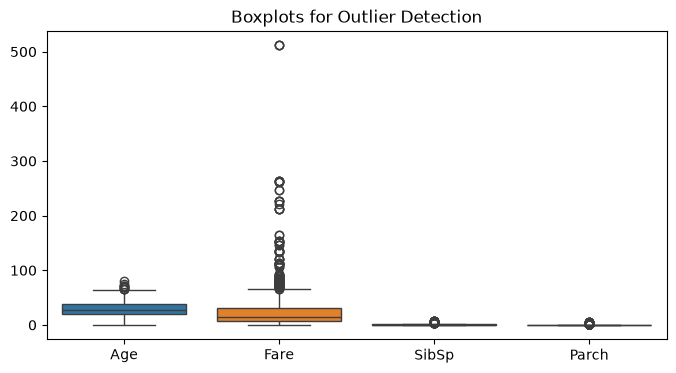

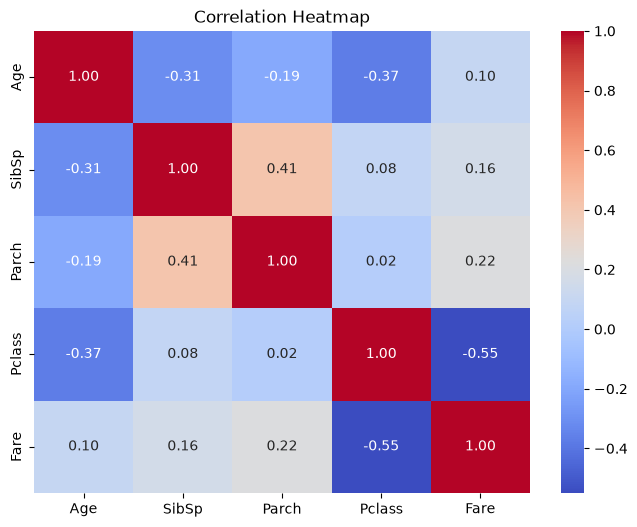

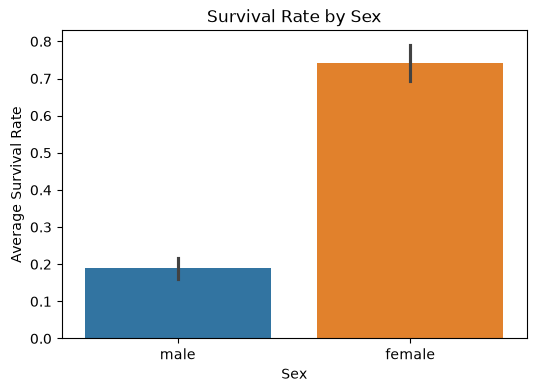

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the CSV File
df = pd.read_csv("Titanic-Dataset.csv")

# 2. Statistical Summaries
print("--- Dataset Info ---")
print(df.info())

print("\n--- Descriptive Statistics (Numerical Features) ---")
print(df.describe())

print("\n--- Missing Values Count ---")
print(df.isnull().sum())

# 3. Visualizations (EDA Plots)
# Histograms for Numerical Features
numeric_cols = ["Age", "Fare", "SibSp", "Parch"]
df[numeric_cols].hist(bins=30, figsize=(10, 6), layout=(2, 2))
plt.suptitle("Feature Distributions (Histograms)", fontsize=14)
plt.tight_layout()
plt.show()

# Boxplots for Outlier Detection
plt.figure(figsize=(8, 4))
sns.boxplot(data=df[numeric_cols])
plt.title("Boxplots for Outlier Detection")
plt.show()

# Correlation Heatmap
selected_cols = ["Age", "SibSp", "Parch", "Pclass", "Fare"]
plt.figure(figsize=(8, 6))
sns.heatmap(df[selected_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# Sex vs Survival Analysis
plt.figure(figsize=(6, 4))
sns.barplot(x="Sex", y="Survived", data=df, hue="Sex", legend=False)
plt.title("Survival Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Average Survival Rate")
plt.show()

Data Preprocessing / Cleaning

In [2]:
# 04 Data Preprocessing / Cleaning

# 1. Check and Remove Duplicate Rows
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
df = df.drop_duplicates().copy()

# 2. Handle Missing Values
# Age mein missing values ko median se fill karenge
df["Age"] = df["Age"].fillna(df["Age"].median())

# Embarked mein missing values ko mode (most frequent value) se fill karenge
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Cabin column mein bohot zyada missing values (~77%) hain, isliye usko drop ya ignore kiya ja sakta hai 
# (Hum baaki important features par focus karenge)

# 3. Correct Inconsistent Data Types & Verify
print("\n--- Missing Values After Cleaning ---")
print(df.isnull().sum())

# 4. Encode Categorical Variables (Sex aur Embarked ko numeric values mein convert karna)
from sklearn.preprocessing import LabelEncoder

label_encoder_sex = LabelEncoder()
df['Sex_Encoded'] = label_encoder_sex.fit_transform(df['Sex'])

label_encoder_embarked = LabelEncoder()
df['Embarked_Encoded'] = label_encoder_embarked.fit_transform(df['Embarked'])

print("\n--- Data Head After Preprocessing & Encoding ---")
print(df[['Survived', 'Pclass', 'Sex', 'Sex_Encoded', 'Age', 'Fare', 'Embarked', 'Embarked_Encoded']].head())

Number of duplicate rows: 0

--- Missing Values After Cleaning ---
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

--- Data Head After Preprocessing & Encoding ---
   Survived  Pclass     Sex  Sex_Encoded   Age     Fare Embarked  \
0         0       3    male            1  22.0   7.2500        S   
1         1       1  female            0  38.0  71.2833        C   
2         1       3  female            0  26.0   7.9250        S   
3         1       1  female            0  35.0  53.1000        S   
4         0       3    male            1  35.0   8.0500        S   

   Embarked_Encoded  
0                 2  
1                 0  
2                 2  
3                 2  
4                 2  


Feature Selection & Engineering

In [3]:
# 05 Feature Selection & Engineering

# 1. Feature Engineering: Naye features banana
# a) FamilySize: SibSp (siblings/spouses) + Parch (parents/children) + 1 (khud passenger)
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# b) IsAlone: Check karna ke passenger akela travel kar raha tha ya family ke sath
df['IsAlone'] = 0
df.loc[df['FamilySize'] == 1, 'IsAlone'] = 1

# c) Title Extraction: Name column se titles (jaise Mr, Mrs, Miss) extract karna
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
# Rare titles ko group kar sakte hain ya Label Encode kar sakte hain
from sklearn.preprocessing import LabelEncoder
title_encoder = LabelEncoder()
df['Title_Encoded'] = title_encoder.fit_transform(df['Title'])

# 2. Feature Selection: Model ke liye sabse relevant features ka subset chunna
selected_features = [
    'Pclass', 
    'Sex_Encoded', 
    'Age', 
    'SibSp', 
    'Parch', 
    'Fare', 
    'Embarked_Encoded', 
    'FamilySize', 
    'IsAlone', 
    'Title_Encoded'
]

target = 'Survived'

# Model dataframe taiyar karna
X = df[selected_features]
y = df[target]

print("--- Selected Features for Model Training ---")
print(selected_features)
print(f"\nShape of Feature Matrix X: {X.shape}")
print(f"Shape of Target Vector y: {y.shape}")

print("\n--- First 5 Rows of Feature Matrix ---")
print(X.head())

--- Selected Features for Model Training ---
['Pclass', 'Sex_Encoded', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Encoded', 'FamilySize', 'IsAlone', 'Title_Encoded']

Shape of Feature Matrix X: (891, 10)
Shape of Target Vector y: (891,)

--- First 5 Rows of Feature Matrix ---
   Pclass  Sex_Encoded   Age  SibSp  Parch     Fare  Embarked_Encoded  \
0       3            1  22.0      1      0   7.2500                 2   
1       1            0  38.0      1      0  71.2833                 0   
2       3            0  26.0      0      0   7.9250                 2   
3       1            0  35.0      1      0  53.1000                 2   
4       3            1  35.0      0      0   8.0500                 2   

   FamilySize  IsAlone  Title_Encoded  
0           2        0             12  
1           2        0             13  
2           1        1              9  
3           2        0             13  
4           1        1             12  


<>:12: SyntaxWarning: invalid escape sequence '\.'
<>:12: SyntaxWarning: invalid escape sequence '\.'
C:\Users\tanzi\AppData\Local\Temp\ipykernel_15628\1181309405.py:12: SyntaxWarning: invalid escape sequence '\.'
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


Split the Dataset

In [4]:
# 06 Split the Dataset
from sklearn.model_selection import train_test_split

# Data ko 80% Training aur 20% Testing mein split karna
# random_state fix karne se split har baar ek jaisa hi rahega (reproducibility ke liye)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("--- Dataset Split Summary ---")
print(f"Total samples in dataset: {len(df)}")
print(f"Training set shape (X_train): {X_train.shape}")
print(f"Testing set shape (X_test): {X_test.shape}")
print(f"Training target shape (y_train): {y_train.shape}")
print(f"Testing target shape (y_test): {y_test.shape}")

--- Dataset Split Summary ---
Total samples in dataset: 891
Training set shape (X_train): (712, 10)
Testing set shape (X_test): (179, 10)
Training target shape (y_train): (712,)
Testing target shape (y_test): (179,)


Model Selection

In [5]:
# 07 Model Selection
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Different models ko dictionaries mein define karna taaki hum easily train aur compare kar sakein
models = {
    "Logistic Regression": LogisticRegression(max_iter=500, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

print("--- Selected Models for Titanic Classification ---")
for name, model in models.items():
    print(f"-> {name}: {model}")

--- Selected Models for Titanic Classification ---
-> Logistic Regression: LogisticRegression(max_iter=500, random_state=42)
-> Decision Tree: DecisionTreeClassifier(random_state=42)
-> Random Forest: RandomForestClassifier(random_state=42)


Model Training

In [6]:
# 08 Model Training

# Dictionary mein train kiye gaye models ko store karne ke liye ek variable
trained_models = {}

print("--- Model Training Started ---")
for name, model in models.items():
    # Model ko training data par fit/train karna
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"Successfully trained: {name}")

print("\nAll models have learned the underlying patterns and are ready for evaluation!")

--- Model Training Started ---
Successfully trained: Logistic Regression
Successfully trained: Decision Tree
Successfully trained: Random Forest

All models have learned the underlying patterns and are ready for evaluation!


Model Evaluation

In [7]:
# 09 Model Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

evaluation_results = {}

print("--- Model Evaluation Results ---")
for name, model in trained_models.items():
    # Test data par predictions karna
    y_pred = model.predict(X_test)
    
    # Metrics calculate karna
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    evaluation_results[name] = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    }
    
    print(f"\nModel: {name}")
    print(f"  - Accuracy  : {acc * 100:.2f}%")
    print(f"  - Precision : {prec:.4f}")
    print(f"  - Recall    : {rec:.4f}")
    print(f"  - F1-Score  : {f1:.4f}")

# Results ko comparison ke liye DataFrame mein convert karna
eval_df = pd.DataFrame(evaluation_results).T
print("\n--- Model Comparison Summary ---")
print(eval_df)

--- Model Evaluation Results ---

Model: Logistic Regression
  - Accuracy  : 79.33%
  - Precision : 0.7681
  - Recall    : 0.7162
  - F1-Score  : 0.7413

Model: Decision Tree
  - Accuracy  : 79.89%
  - Precision : 0.7375
  - Recall    : 0.7973
  - F1-Score  : 0.7662

Model: Random Forest
  - Accuracy  : 82.12%
  - Precision : 0.7838
  - Recall    : 0.7838
  - F1-Score  : 0.7838

--- Model Comparison Summary ---
                     Accuracy  Precision    Recall  F1-Score
Logistic Regression  0.793296   0.768116  0.716216  0.741259
Decision Tree        0.798883   0.737500  0.797297  0.766234
Random Forest        0.821229   0.783784  0.783784  0.783784


Hyperparameter Tuning

In [8]:
# 10 Hyperparameter Tuning using GridSearchCV
from sklearn.model_selection import GridSearchCV

# Random Forest ke liye hyperparameters ka grid define karna
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Base model create karna
rf = RandomForestClassifier(random_state=42)

# GridSearchCV setup karna (5-fold cross-validation ke sath)
grid_search = GridSearchCV(
    estimator=rf, 
    param_grid=param_grid, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1
)

print("--- Hyperparameter Tuning Started (Grid Search) ---")
grid_search.fit(X_train, y_train)

# Best parameters aur best score print karna
print("\n--- Tuning Results ---")
print(f"Best Hyperparameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_ * 100:.2f}%")

# Best tuned model ko test set par evaluate karna
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)

print(f"Tuned Model Test Accuracy: {tuned_accuracy * 100:.2f}%")

--- Hyperparameter Tuning Started (Grid Search) ---

--- Tuning Results ---
Best Hyperparameters: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Best Cross-Validation Accuracy: 83.14%
Tuned Model Test Accuracy: 82.68%


Model Testing / Validation

--- Final Model Testing & Validation Summary ---
Final Unseen Test Accuracy  : 82.68%
Final Unseen Test Precision : 0.7838
Final Unseen Test Recall    : 0.7838
Final Unseen Test F1-Score  : 0.7838


<Figure size 600x400 with 0 Axes>

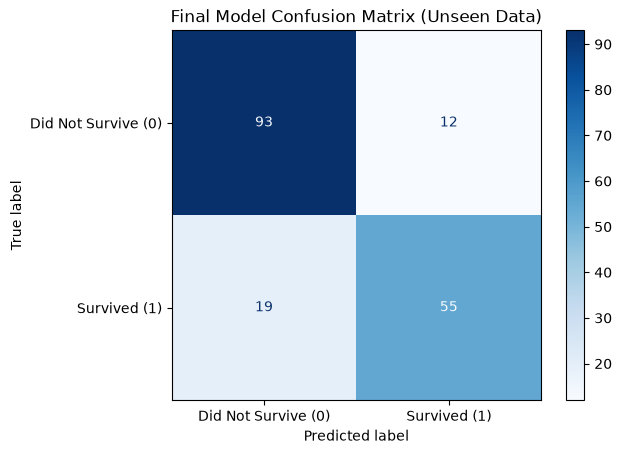

In [9]:
# 11 Model Testing / Validation on Unseen Test Set
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Kyunki humne pehle hi X_test aur y_test ko training process se bilkul alag (unseen) rakha hai,
# yeh hamara final validation dataset hai.
final_y_pred = best_model.predict(X_test)

# Final performance metrics
final_accuracy = accuracy_score(y_test, final_y_pred)
final_precision = precision_score(y_test, y_pred)
final_recall = recall_score(y_test, y_pred)
final_f1 = f1_score(y_test, y_pred)

print("--- Final Model Testing & Validation Summary ---")
print(f"Final Unseen Test Accuracy  : {final_accuracy * 100:.2f}%")
print(f"Final Unseen Test Precision : {final_precision:.4f}")
print(f"Final Unseen Test Recall    : {final_recall:.4f}")
print(f"Final Unseen Test F1-Score  : {final_f1:.4f}")

# Confusion Matrix visualization for final validation
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, final_y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Did Not Survive (0)', 'Survived (1)'])
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Final Model Confusion Matrix (Unseen Data)")
plt.show()

In [10]:
import pickle

# 1. Best Tuned Model ko save karna
with open('titanic_model.pkl', 'wb') as file:
    pickle.dump(best_model, file)

# 2. Categorical Encoders ko save karna (taaki UI mein user input ko encode kar sakein)
with open('sex_encoder.pkl', 'wb') as file:
    pickle.dump(label_encoder_sex, file)
    
with open('embarked_encoder.pkl', 'wb') as file:
    pickle.dump(label_encoder_embarked, file)

with open('title_encoder.pkl', 'wb') as file:
    pickle.dump(title_encoder, file)

print("Model and Encoders successfully saved!")

Model and Encoders successfully saved!
